In [ ]:

# why multi-head is better than single-head ? 

# https://gemini.google.com/app/8720e969a2fcbae5
# The Averaging Bottleneck (Single Head)
# Representation Subspaces (Multi-Head)
# The Computational Equivalence

# too many heads:
#   Dot-product discriminability collapses: In a d_head-dimensional random projection, the variance of the dot product between two vectors scales with d_head, When d_head gets very small, there just isn't enough room for queries/keys to be pushed far apart in angle — random or near-random keys start looking similar to a query, so the softmax degenerates toward uniform, You get noise-induced averaging, which is the same symptom you were trying to escape (uniform attention), just caused by insufficient dimensionality instead of a forced single softmax.
#   Johnson–Lindenstrauss-style capacity limit. To keep pairwise angular relationships between N distinguishable concepts roughly preserved under a linear projection, you need roughly d_head = O(log N / ε²) dimensions. Below that, key vectors for genuinely different tokens start colliding in the projected space — the head physically cannot keep enough patterns separable   


# pay-off curve = inverted-U
# 
# performance
    # ^
    # |         ____________
    # |       /              \___
    # |      /                    \___
    # |     /                          \
    # |    /
    # |   /
    # +--+---------------------------------> h (num heads, d_head = d_model/h)
    #    1    few heads    "sweet spot"    many tiny heads
    #    (averaging       (diverse, still  (noisy dot products,
    #     bottleneck)      well-powered)    redundant/collapsing heads)
#  


# Multi-head splitting trades a combinatorial bottleneck (can't represent multiple relations at once) for a dimensionality/statistical 
# bottleneck (each relation is represented too weakly to be reliably distinguished). The optimum sits where you've captured most of the 
# useful "different relation types need different heads" benefit before dot-product signal-to-noise per head starts degrading — empirically, 
# that's around d_head ≈ 64–128 for typical model/vocab scales, largely independent of total model size.


#---
# implement YaRN for positinal encodings, QK norm

# MHA: num_query_heads == num_kv_heads
# GQA: 1 < num_kv_heads < num_query_heads and num_query_heads % num_kv_heads == 0
# MQA: num_kv_heads == 1


# TODO:

# line-by-line explaination of this script, weight init method used, RoPE rewrite, compute graph vis, tensor health check, attentino map vis
# make a report on: SHA/MQA/GQA/MHA performance/cost 
# reposr benchmark: cached vs. uncached decode latency as sequence length grows

Give an efficient pytorch implementation for grouped query attention with RoPE and kv caching, in 3 python classes, sub_block, block and model. Use einops to clarify every tensor operation, use a dedicated KV cache data class, give clear and explicit names to tensors and their dimensions and write out their operation in einops strings step-by-step. for efficiency precompute RoPE, but know that during inference it is possible to generate beyond the pre-set max_seq_len yet only using the last context_window length number of tokens for next token prediction, while the KV cache which is also statically pre-allocated will only keep the last max_seq_len number of tokens, let the cache object do the management so the attention module stays cleaner. I will use torch.nn.functional.scaled_dot_product_attention with isCausal=True, 

---



In [ ]:
import os
import sys
import math
import time
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple
from einops import rearrange, reduce, repeat, einsum, pack


import training_engine as training_engine 
from utils import init_custom_weight, inspect_tensor
from inference_engine import advanced_inference, KV_cache


MODEL_CONFIGS_lvl2 = {

    "model_name" : "level2_attention_models",

    "tied_embeddings" : True,  # tie input and output embeddings

    "embed_dim"   : 2**5,   # 32
    "vocab_size"  : 2**11,  # 2048
    "num_layers"  : 5,

    "max_context_window" : 2**6,   # 64

    "num_q_heads" : 2**0, # 1 | 1   x   x    x
    # ------------------------------------------ 
    "num_kv_heads": 2**0, # 1 | 1   1   2+   x
   
    "max_training_batch_size": 2**4,   # 16
   
    "learning_rate" : 1e-3,

    "rope_theta": 10000.0,
    "rope_max_seq_len": 1000,   # pre-compute RoPE this far (or grow dynamically)
    
    "save_path"    : "../models/level3_attention_models.pt",
    "loss_history" : "../models/level3_attention_models_loss_history.txt",
}


# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ! will NEED PyTorch version 2.5+
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version:   {torch.version.cuda}")
    print(f"GPU:            {torch.cuda.get_device_name(0)}")

PyTorch:        2.8.0+cu129
CUDA available: True
CUDA version:   12.9
GPU:            NVIDIA GeForce GTX 1660 Ti


In [ ]:
@dataclass(frozen=True)
class ModelConfig:
    model_name: str = "level2_attention_models"


    @property
    def head_dim(self):
        return self.embed_dim // self.num_q_heads

    @property
    def num_groups(self):
        return self.num_q_heads // self.num_kv_heads


    def __post_init__(self):
        if self.embed_dim % self.num_q_heads != 0:
            raise ValueError(
                "embed_dim must be divisible by num_q_heads"
            )

        if self.num_q_heads % self.num_kv_heads != 0:
            raise ValueError(
                "num_q_heads must be divisible by num_kv_heads"
            )

configs = ModelConfig()
print(configs)

In [3]:
class RotaryEmbedding(nn.Module):

    def __init__(self, config:dict, device=device):
        super().__init__()

        base     = config["rope_theta"]
        head_dim = config["embed_dim"] // config["num_q_heads"]

        # shape: [head_dim // 2]
        inv_freq = 1.0 / (
            base ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim)
        )
        self.register_buffer("inv_freq", inv_freq, persistent=False)


    def forward(
            self,
            position_ids: torch.Tensor,   # [B, seq] or [seq]
            dtype= torch.float32,
        ) -> tuple[torch.Tensor, torch.Tensor]:

            if position_ids.dim() == 1:
                position_ids = position_ids.unsqueeze(0)          # [1, seq]

            # position_ids: [B, seq]  (integer)
            # inv_freq:     [head_dim//2]
            # freqs:        [B, seq, head_dim//2]

            inv_freq = self.inv_freq.to(device=position_ids.device)

            freqs = torch.einsum(
                "bi,j->bij",
                position_ids.to(dtype=inv_freq.dtype),
                inv_freq,
            )

            emb = torch.cat((freqs, freqs), dim=-1)               # [B, seq, head_dim]
            cos = emb.cos().to(dtype=dtype)
            sin = emb.sin().to(dtype=dtype)

            # broadcast over the head dimension → [B, 1, seq, head_dim]
            return cos.unsqueeze(1), sin.unsqueeze(1)

    def _build_cache(self, seq_len: int):
        t = torch.arange(seq_len, device=device, dtype=self.inv_freq.dtype)
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer("cos_cached", emb.cos(), persistent=False)
        self.register_buffer("sin_cached", emb.sin(), persistent=False)
        self.max_seq_len = seq_len



def rotate_half(x: torch.Tensor) -> torch.Tensor:
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(
    q:   torch.Tensor,
    k:   torch.Tensor,
    cos: torch.Tensor,
    sin: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    
    # last-resort safety – should not be needed after the fixes above
    cos = cos.to(device=q.device, dtype=q.dtype)
    sin = sin.to(device=q.device, dtype=q.dtype)

    q = (q * cos) + (rotate_half(q) * sin)
    k = (k * cos) + (rotate_half(k) * sin)
    return q, k

In [4]:
class Attention_SubBlock(nn.Module):

    def __init__(self, config):
        super().__init__()

        self.embed_dim = config["embed_dim"]

        self.num_q_heads = config["num_q_heads"]
        self.num_kv_heads = config["num_kv_heads"]

        assert self.embed_dim % self.num_q_heads == 0, \
        "embed_dim must be divisible by num_q_heads"

        assert self.num_q_heads % self.num_kv_heads == 0, \
        "num_q_heads must be divisible by num_kv_heads"

        self.head_dim = self.embed_dim // self.num_q_heads

        self.W_q = nn.Parameter(torch.empty(self.embed_dim, self.num_q_heads  * self.head_dim))
        self.W_k = nn.Parameter(torch.empty(self.embed_dim, self.num_kv_heads * self.head_dim))
        self.W_v = nn.Parameter(torch.empty(self.embed_dim, self.num_kv_heads * self.head_dim))
        self.W_o = nn.Parameter(torch.empty(self.num_q_heads  * self.head_dim, self.embed_dim))

        self.init_params(config)


    def init_params(self, config):
        # Standard projections
        init_custom_weight(self.W_q, is_residual_output=False)
        init_custom_weight(self.W_k, is_residual_output=False)
        init_custom_weight(self.W_v, is_residual_output=False)

        # Residual output projection (scaled by depth)
        init_custom_weight(self.W_o, is_residual_output=True, 
                           num_layers=config["num_layers"])



    def forward(
        self,
        x: torch.Tensor,
        cos: torch.Tensor,          # [B, 1, seq, head_dim] – already computed
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,
    ) -> torch.Tensor:

        batch_size, seq_len, embed_dim = x.shape


        # ─────────────────────────────────────────────
        # Query projection
        # ─────────────────────────────────────────────

        q = einsum(
            x,
            self.W_q,
            "batch_size seq_len embed_dim, "
            "embed_dim q_projection_dim -> "
            "batch_size seq_len q_projection_dim",
        )

        q = rearrange(
            q,
            "batch_size seq_len (num_q_heads head_dim) "
            "-> batch_size num_q_heads seq_len head_dim",
            num_q_heads=self.num_q_heads,
        )


        # ─────────────────────────────────────────────
        # Key projection
        # ─────────────────────────────────────────────

        k = einsum(
            x,
            self.W_k,
            "batch_size seq_len embed_dim, "
            "embed_dim kv_projection_dim -> "
            "batch_size seq_len kv_projection_dim",
        )

        k = rearrange(
            k,
            "batch_size seq_len (num_kv_heads head_dim) "
            "-> batch_size num_kv_heads seq_len head_dim",
            num_kv_heads=self.num_kv_heads,
        )


        # ─────────────────────────────────────────────
        # Value projection
        # ─────────────────────────────────────────────

        v = einsum(
            x,
            self.W_v,
            "batch_size seq_len embed_dim, "
            "embed_dim kv_projection_dim -> "
            "batch_size seq_len kv_projection_dim",
        )

        v = rearrange(
            v,
            "batch_size seq_len (num_kv_heads head_dim) "
            "-> batch_size num_kv_heads seq_len head_dim",
            num_kv_heads=self.num_kv_heads,
        )

        # ---

        q, k = apply_rotary_pos_emb(q, k, cos, sin)

        if cache is not None:
            k, v = cache.update(layer_idx, k, v)


        out = F.scaled_dot_product_attention(
            q, k, v,
            is_causal=(q.shape[2] == k.shape[2]),
            enable_gqa=(self.num_q_heads != self.num_kv_heads),
        )


        # Merge attention heads
        out = rearrange(
            out,
            "batch_size num_q_heads seq_len head_dim "
            "-> batch_size seq_len (num_q_heads head_dim)",
        )


        # Output projection
        out = einsum(
            out,
            self.W_o,
            "batch_size seq_len q_projection_dim, "
            "q_projection_dim embed_dim "
            "-> batch_size seq_len embed_dim",
        )


        return out

In [5]:
class Transformer_Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.attention_sub_block = Attention_SubBlock(config)
        self.norm = nn.RMSNorm(config["embed_dim"])


    def forward(
        self,
        x: torch.Tensor,
        cos: torch.Tensor,
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,
    ) -> torch.Tensor:
        
        residual = x

        x = self.norm(x)
        x = self.attention_sub_block(x, cos, sin, cache=cache, layer_idx=layer_idx)
        x = x + residual
        
        return x


In [6]:
class Level2_Model(nn.Module):

    def __init__(self, config=MODEL_CONFIGS_lvl2):
        super().__init__()

        self.vocab_size = config["vocab_size"]
        self.embed_dim  = config["embed_dim"]        


        self.embed  = nn.Parameter(torch.empty(self.vocab_size, self.embed_dim))

        self.rotary = RotaryEmbedding(config)

        self.layers = nn.ModuleList([Transformer_Block(config) for _ in range(config["num_layers"])])

        self.final_rms_norm = nn.RMSNorm(config["embed_dim"])

        self.unembed = nn.Parameter(torch.empty(self.embed_dim, self.vocab_size))

        self.init_params()



    def init_params(self):
        init_custom_weight(self.embed,   is_residual_output=False)
        init_custom_weight(self.unembed, is_residual_output=False)


    def forward(
            self, 
            input_ids: torch.tensor, 
            cache: Optional[KV_cache] = None,
            position_ids: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:

        batch_size, seq_len = input_ids.shape

        # [batch_size, seq_len] -> [batch_size, seq_len, embed_dim]
        x = self.embed[input_ids] 

        device = input_ids.device          # ← single source of truth
        # print('input_ids.device -> ', input_ids.device)

        if position_ids is None:
            if cache is not None and cache.current_abs_pos > 0:
                start = cache.current_abs_pos
                position_ids = torch.arange(
                    start, start + seq_len, device=device, dtype=torch.long
                )
            else:
                position_ids = torch.arange(
                    seq_len, device=device, dtype=torch.long
                )
        else:
            # caller-supplied ids must also be on the right device
            position_ids = position_ids.to(device=device, dtype=torch.long)

        if position_ids.dim() == 1:
            position_ids = position_ids.unsqueeze(0).expand(batch_size, -1)

        cos, sin = self.rotary(position_ids, dtype=x.dtype)
        
        for i, layer in enumerate(self.layers):
                x = layer(x, cos, sin, cache=cache, layer_idx=i)        

        x = self.final_rms_norm(x)
        
        logits = einsum(x, self.unembed, 
                        "batch_size seq_len embed_dim, " 
                        "embed_dim vocab_size"
                        " -> "
                        "batch_size seq_len vocab_size")

        return logits

Step 0000 | Batch Loss: 7.6296 nats
Step 0005 | Batch Loss: 7.6102 nats
Step 0010 | Batch Loss: 7.5777 nats
Step 0015 | Batch Loss: 7.5260 nats
Step 0020 | Batch Loss: 7.4780 nats
Step 0025 | Batch Loss: 7.4258 nats
Step 0030 | Batch Loss: 7.3725 nats
Step 0035 | Batch Loss: 7.2778 nats
Step 0040 | Batch Loss: 7.2290 nats
Step 0045 | Batch Loss: 7.2073 nats
Step 0050 | Batch Loss: 7.1717 nats
Step 0055 | Batch Loss: 7.1395 nats
Step 0060 | Batch Loss: 7.1461 nats
Step 0065 | Batch Loss: 7.1226 nats
Step 0070 | Batch Loss: 7.0757 nats
Step 0075 | Batch Loss: 7.1127 nats
Step 0080 | Batch Loss: 7.0561 nats
Step 0085 | Batch Loss: 7.0302 nats
Step 0090 | Batch Loss: 7.0047 nats
Step 0095 | Batch Loss: 6.9953 nats
Step 0099 | Batch Loss: 7.0245 nats

Saving model weights to: ../models/level3_attention_models.pt
Loss history successfully saved to ../models/level3_attention_models_loss_history.txt
Loaded 100 steps from ../models/level3_attention_models_loss_history.txt


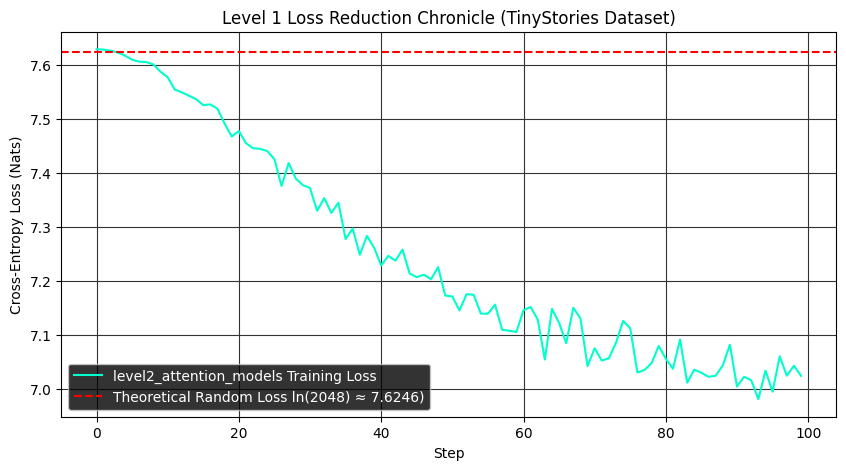

Loaded state_dict from ..\models\level3_attention_models.pt
Number of parameter tensors: 28
Number of parameters: 151,744

PARAMETER SUMMARY
embed: shape=(2048, 32), dtype=torch.float32, requires_grad=False, numel=65,536
unembed: shape=(32, 2048), dtype=torch.float32, requires_grad=False, numel=65,536
layers.0.attention_sub_block.W_q: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
layers.0.attention_sub_block.W_k: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
layers.0.attention_sub_block.W_v: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
layers.0.attention_sub_block.W_o: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
layers.0.norm.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
layers.1.attention_sub_block.W_q: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
layers.1.attention_sub_block.W_k: shape=(32, 32), dtype=torch.float32, requires_grad=False,

In [7]:


model = Level2_Model()

configs = MODEL_CONFIGS_lvl2


if torch.cuda.is_available():
    torch.cuda.synchronize()
start = time.time()


training_engine.train_and_save_model(model, configs, device, 100)
training_engine.plot_loss_history(configs)
training_engine.inspect_weight_file(configs["save_path"])

if torch.cuda.is_available():
    torch.cuda.synchronize()
total_time = time.time() - start



if torch.cuda.is_available():
    max_mem_bytes = torch.cuda.max_memory_allocated()
    max_mem_gb = max_mem_bytes / (1024 ** 3)
    print(f"Max memory allocated: {max_mem_gb:.2f} GB")


In [8]:
eos_id = 83

# use "continuous batching" to pack same-length prompts together 
prompt_strs = [
    "write a story about",
    "write like a little boy that was angry",
    "write as a little boy that was happy,",
] # 3 prompts each w/ len of 8.


result = advanced_inference(model,
                             configs, 
                            num_gen_steps=33, 
                            prompt_strs=prompt_strs, 
                            device=device, 
                            eos_token_id=eos_id
                            ) # [batch_size, prompt_len + num_get_steps]

for prmpt in result:
    print("---"*80)
    print(prmpt)


[INFO] Loaded weights from ../models/level3_attention_models.pt  (151,744 parameters)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
inyou  . The her . They edting it  the e 
s and sitbig ep. He ing the et <|endoftext|>t<|endoftext|>ethe . He k. The 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ly 
Once upon a time, dtand le  the it the in the ps. , s es
aand 
<|endoftext|> and to s. She sit m. He ed the 
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------